In [1]:
# Cell 1 — Install TRIBE v2 and dependencies
!git clone https://github.com/facebookresearch/tribev2.git
%cd tribev2
!pip install -e . -q
!pip install -e ".[plotting]" -q   # adds brain-visualization deps (nilearn etc.)

Cloning into 'tribev2'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 65 (delta 21), reused 9 (delta 9), pack-reused 13 (from 2)
Receiving objects: 100% (65/65), 3.49 MiB | 18.04 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/kaggle/working/tribev2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.1/258.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 10

In [9]:
# Cell 2 — HuggingFace login
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)
print("Logged in to HuggingFace.")

Logged in to HuggingFace.


In [10]:
# Cell 3 (updated) — Find audio, then COPY it to a writable location
import glob, os, shutil

candidates = glob.glob("/kaggle/input/datasets/rithikhchandran/demoaudio/output.wav", recursive=True)
audio_files = [f for f in candidates if f.lower().endswith((".wav", ".mp3", ".flac", ".m4a", ".ogg"))]
print("Audio files found:", audio_files)

src = audio_files[0]   # or hard-code your exact input path

# Copy into writable working dir so TRIBE can write its transcript .tsv alongside it
work_dir = "/kaggle/working/audio_in"
os.makedirs(work_dir, exist_ok=True)
AUDIO_PATH = os.path.join(work_dir, os.path.basename(src))
shutil.copy(src, AUDIO_PATH)

print("Using writable copy:", AUDIO_PATH)

Audio files found: ['/kaggle/input/datasets/rithikhchandran/demoaudio/output.wav']
Using writable copy: /kaggle/working/audio_in/output.wav


In [11]:
# Cell 4 (unchanged logic) — Load TRIBE v2 and run inference
import torch
from tribev2 import TribeModel

print("CUDA available:", torch.cuda.is_available())

model = TribeModel.from_pretrained("facebook/tribev2", cache_folder="./cache")

df = model.get_events_dataframe(audio_path=AUDIO_PATH)
print("Events dataframe shape:", df.shape)

preds, segments = model.predict(events=df)
print("Predictions shape:", preds.shape)

CUDA available: True


/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-06-17 13:31:11 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 199.65it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add con

Events dataframe shape: (4, 20)


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[13:32:05 INFO] Preparing extractor: subject_id
2026-06-17 13:32:05 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[13:32:06 INFO] Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.36s/it]
INFO - Predicted 31 / 100 segments (31.0% kept)


Predictions shape: (31, 20484)


In [12]:
# Cell 5 — Save predictions
import numpy as np

np.save("/kaggle/working/brain_predictions.npy", preds)
print("Saved to /kaggle/working/brain_predictions.npy")
print("Shape:", preds.shape, "| min:", preds.min(), "max:", preds.max())

Saved to /kaggle/working/brain_predictions.npy
Shape: (31, 20484) | min: -0.72389865 max: 0.5857753


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d63704a4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-32a4b2

Saved brain_left.png and brain_right.png


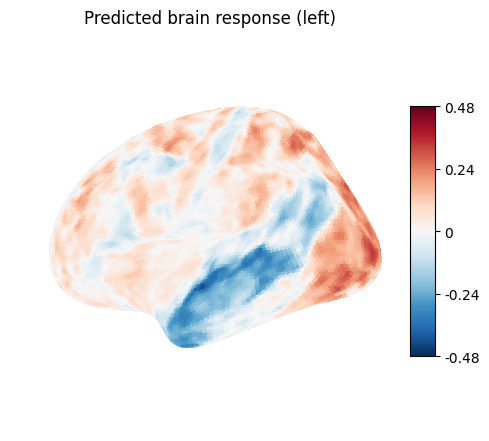

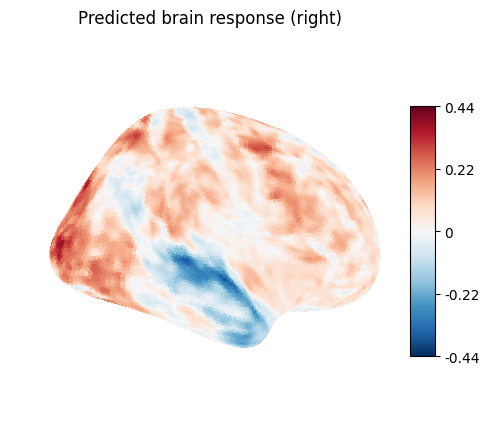

In [13]:
# Cell 6 — Brain visualization
import numpy as np
from nilearn import datasets, plotting

mean_response = preds.mean(axis=0)   # average across time → (n_vertices,)

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
n = mean_response.shape[0]
half = n // 2

plotting.plot_surf_stat_map(
    fsaverage.infl_left, mean_response[:half],
    hemi="left", title="Predicted brain response (left)",
    colorbar=True, bg_map=fsaverage.sulc_left,
).savefig("/kaggle/working/brain_left.png", dpi=150)

plotting.plot_surf_stat_map(
    fsaverage.infl_right, mean_response[half:],
    hemi="right", title="Predicted brain response (right)",
    colorbar=True, bg_map=fsaverage.sulc_right,
).savefig("/kaggle/working/brain_right.png", dpi=150)

print("Saved brain_left.png and brain_right.png")

In [15]:
# Cell A — audio + GIF libraries
!pip install librosa imageio -q

Loaded audio: 30.00s @ 44100 Hz


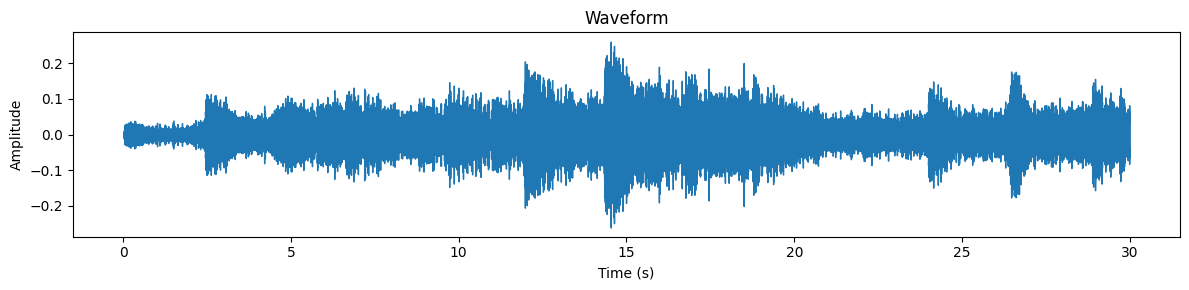

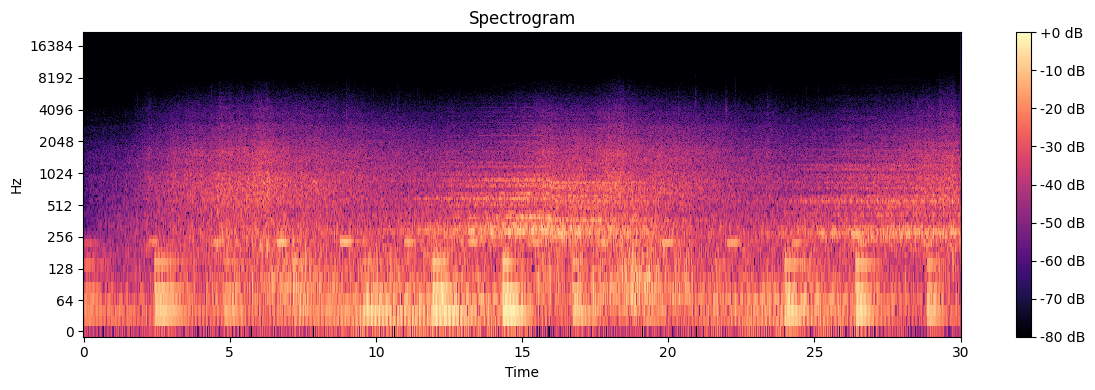

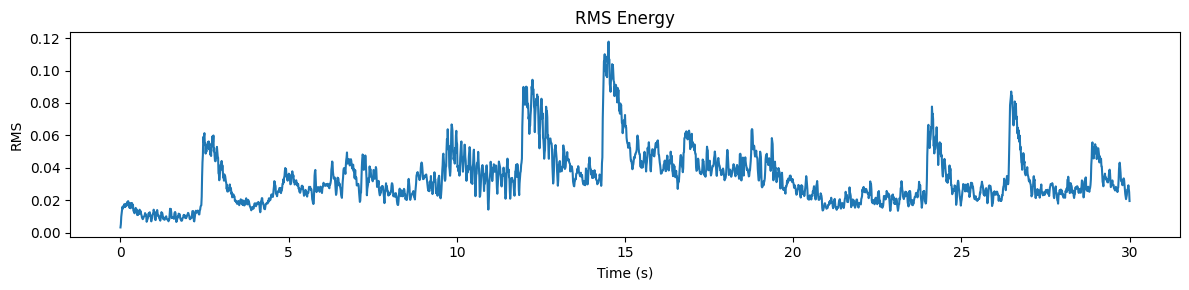

Saved waveform.png, spectrogram.png, rms.png, rms_raw.npy


In [16]:
# Cell B — Audio analysis: waveform, spectrogram, RMS
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt

OUT = "/kaggle/working"

y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
duration = len(y) / sr
print(f"Loaded audio: {duration:.2f}s @ {sr} Hz")

# --- Waveform ---
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform"); plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.tight_layout(); plt.savefig(f"{OUT}/waveform.png", dpi=150); plt.show()

# --- Spectrogram (dB) ---
S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB"); plt.title("Spectrogram")
plt.tight_layout(); plt.savefig(f"{OUT}/spectrogram.png", dpi=150); plt.show()

# --- RMS energy envelope ---
hop = 512
rms = librosa.feature.rms(y=y, hop_length=hop)[0]
rms_t = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)
plt.figure(figsize=(12, 3))
plt.plot(rms_t, rms)
plt.title("RMS Energy"); plt.xlabel("Time (s)"); plt.ylabel("RMS")
plt.tight_layout(); plt.savefig(f"{OUT}/rms.png", dpi=150); plt.show()

np.save(f"{OUT}/rms_raw.npy", np.vstack([rms_t, rms]))
print("Saved waveform.png, spectrogram.png, rms.png, rms_raw.npy")

In [17]:
# Cell C — Raw brain reaction, per-timestep metrics, timestamps
import numpy as np, pandas as pd

preds = np.asarray(preds)            # (n_timesteps, n_vertices)
n_t, n_v = preds.shape
print("preds shape:", preds.shape)

# --- reaction_raw: save the full prediction matrix ---
np.save(f"{OUT}/reaction_raw.npy", preds)

# --- brain timestamps ---
# TRIBE predicts at the fMRI sampling rate, offset 5s into the past for hemodynamic lag.
# Try to read true timing from `segments`; otherwise space evenly across audio duration.
try:
    seg = pd.DataFrame(segments)
    if "onset" in seg.columns:
        timestamps = seg["onset"].to_numpy()[:n_t]
    else:
        raise ValueError
except Exception:
    timestamps = np.linspace(0, duration, n_t, endpoint=False)

if len(timestamps) != n_t:                       # safety fallback
    timestamps = np.linspace(0, duration, n_t, endpoint=False)

np.save(f"{OUT}/brain_timestamps.npy", timestamps)

# --- metrics_raw: per-timestep summary statistics ---
metrics = pd.DataFrame({
    "timestamp_s": timestamps,
    "mean":   preds.mean(axis=1),
    "std":    preds.std(axis=1),
    "min":    preds.min(axis=1),
    "max":    preds.max(axis=1),
    "l2_norm": np.linalg.norm(preds, axis=1),
})
metrics.to_csv(f"{OUT}/metrics_raw.csv", index=False)
print(metrics.head())
print("Saved reaction_raw.npy, brain_timestamps.npy, metrics_raw.csv")

preds shape: (31, 20484)
   timestamp_s      mean       std       min       max    l2_norm
0     0.000000 -0.000793  0.104942 -0.601831  0.248930  15.019913
1     0.967748  0.011544  0.111569 -0.610795  0.277959  16.053221
2     1.935496  0.018883  0.119978 -0.645019  0.305897  17.382845
3     2.903243  0.017411  0.103820 -0.618292  0.283880  15.066472
4     3.870991  0.030505  0.124501 -0.655252  0.380753  18.345926
Saved reaction_raw.npy, brain_timestamps.npy, metrics_raw.csv


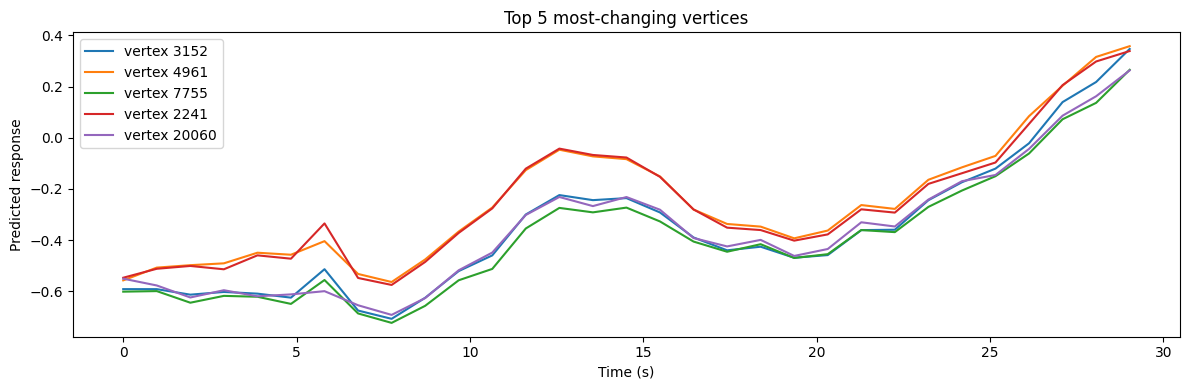

   vertex_index  variance hemisphere
0          3152  0.067941       left
1          4961  0.060421       left
2          7755  0.060001       left
3          2241  0.059428       left
4         20060  0.059047      right
5          3154  0.058888       left
6          4953  0.058721       left
7          7754  0.057660       left
8          4954  0.056927       left
9          3156  0.056144       left


In [18]:
# Cell D — Vertices that change most over time
import numpy as np, pandas as pd

vertex_var = preds.var(axis=0)                 # temporal variance per vertex
top_k = 50
top_idx = np.argsort(vertex_var)[::-1][:top_k]

top_df = pd.DataFrame({
    "vertex_index": top_idx,
    "variance": vertex_var[top_idx],
    "hemisphere": ["left" if i < n_v // 2 else "right" for i in top_idx],
})
top_df.to_csv(f"{OUT}/top_changing_vertices.csv", index=False)

# Plot time-courses of the top 5
plt.figure(figsize=(12, 4))
for i in top_idx[:5]:
    plt.plot(timestamps, preds[:, i], label=f"vertex {i}")
plt.title("Top 5 most-changing vertices"); plt.xlabel("Time (s)"); plt.ylabel("Predicted response")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/top_changing_vertices.png", dpi=150); plt.show()
print(top_df.head(10))

In [19]:
# Cell E — Animated brain response GIF
import numpy as np, imageio.v2 as imageio, os, matplotlib.pyplot as plt
from nilearn import datasets, plotting

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
half = n_v // 2

# Fixed color scale across all frames so brightness is comparable
vmax = np.percentile(np.abs(preds), 99)

# Subsample frames to keep render time reasonable (max ~60 frames)
max_frames = 60
frame_idx = np.linspace(0, n_t - 1, min(n_t, max_frames)).astype(int)

frame_dir = f"{OUT}/frames"; os.makedirs(frame_dir, exist_ok=True)
paths = []
for k, t in enumerate(frame_idx):
    fig = plotting.plot_surf_stat_map(
        fsaverage.infl_left, preds[t, :half], hemi="left",
        bg_map=fsaverage.sulc_left, vmax=vmax, colorbar=True,
        title=f"t = {timestamps[t]:.1f}s",
    )
    p = f"{frame_dir}/frame_{k:03d}.png"
    fig.savefig(p, dpi=90); plt.close(fig); paths.append(p)

images = [imageio.imread(p) for p in paths]
imageio.mimsave(f"{OUT}/brain_response.gif", images, duration=0.3)
print("Saved brain_response.gif")

Saved brain_response.gif


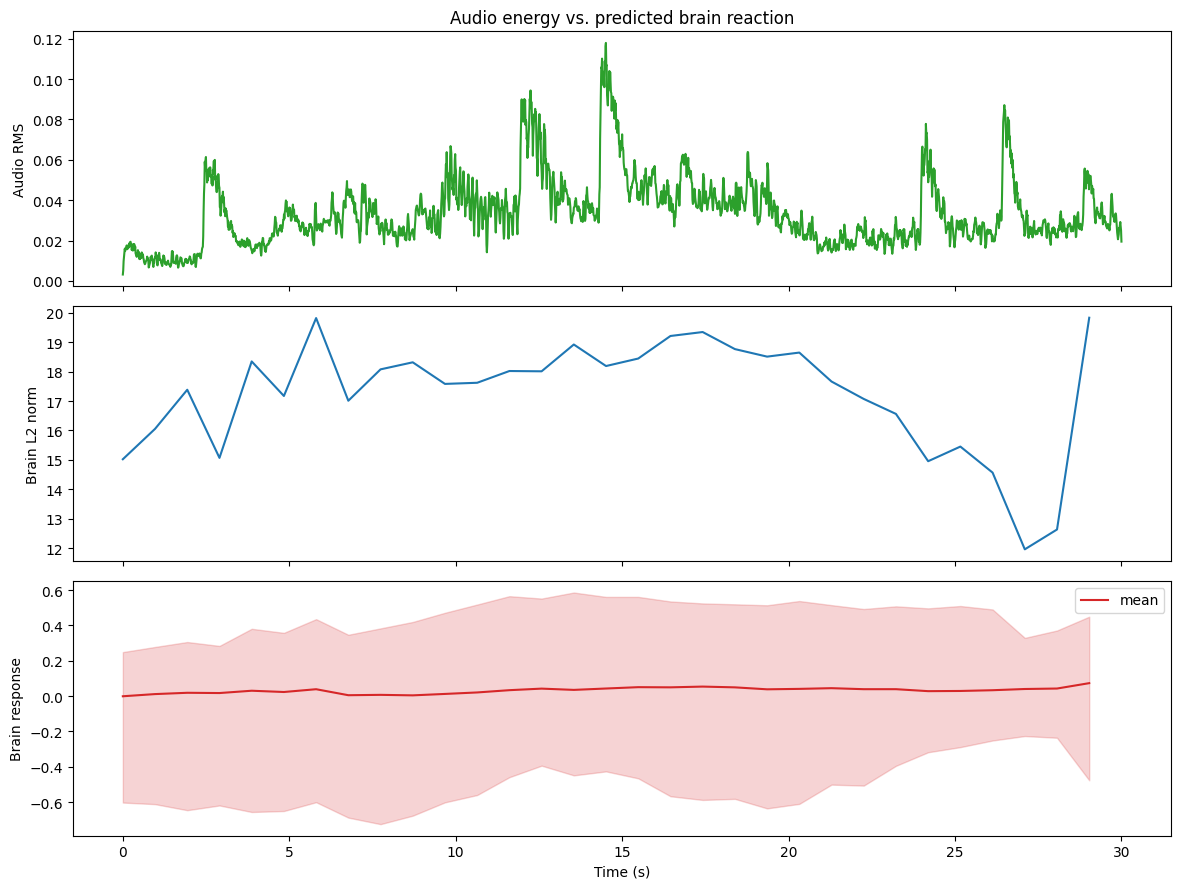

Saved summary_plots.png


In [20]:
# Cell F — Combined summary figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(rms_t, rms, color="tab:green")
ax[0].set_ylabel("Audio RMS"); ax[0].set_title("Audio energy vs. predicted brain reaction")

ax[1].plot(timestamps, metrics["l2_norm"], color="tab:blue")
ax[1].set_ylabel("Brain L2 norm")

ax[2].plot(timestamps, metrics["mean"], color="tab:red", label="mean")
ax[2].fill_between(timestamps, metrics["min"], metrics["max"], alpha=0.2, color="tab:red")
ax[2].set_ylabel("Brain response"); ax[2].set_xlabel("Time (s)"); ax[2].legend()

plt.tight_layout(); plt.savefig(f"{OUT}/summary_plots.png", dpi=150); plt.show()
print("Saved summary_plots.png")